## Análisis diferencias entre sCMBs generadas y rCMBs

### Dataset 111

100%|██████████| 57/57 [00:07<00:00,  7.59it/s]
/tmp/ipykernel_259501/3012404311.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='tipo', y='intensidad', data=pd.DataFrame(centroid_data),


Análisis finalizado.


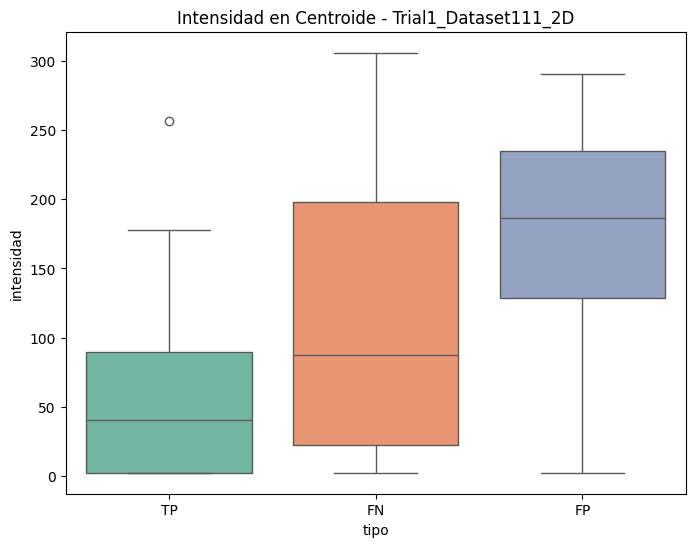

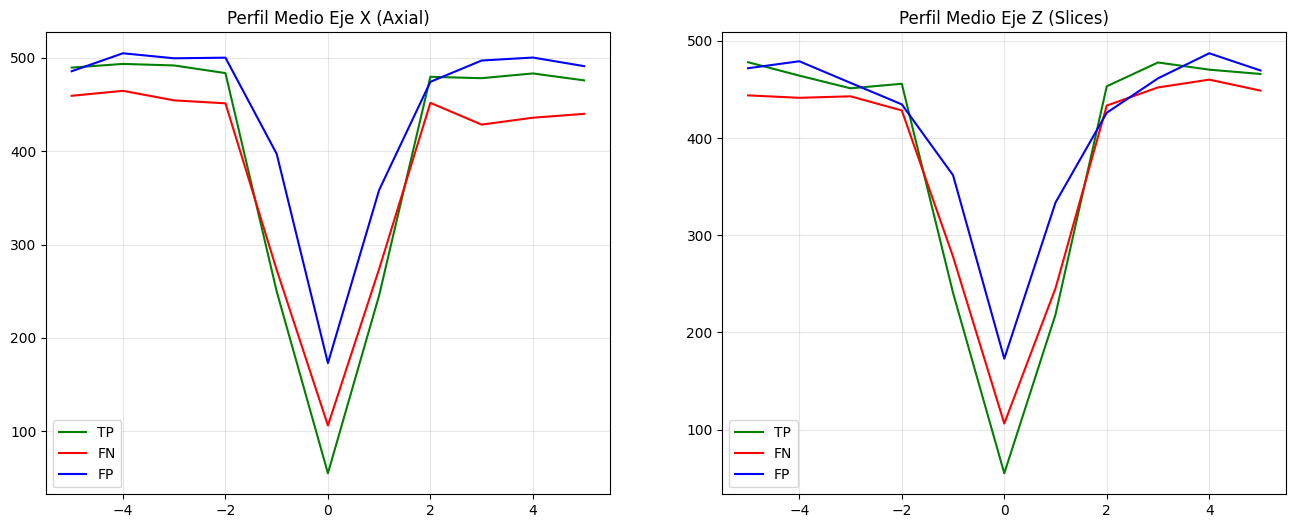

In [14]:
import os
import numpy as np
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.measure import label, regionprops
from tqdm import tqdm

# =================================================================
# CONFIGURACIÓN (Cambiar para Trial 1 y Trial 2)
# =================================================================
TRIAL_NAME = "Trial1_Dataset111_2D" 
EXCEL_PATH = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/CSIRO/CSIRO_dataset/rCMBInformationInfo.xlsx"
MASK_DIR = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/CSIRO/nnUNet_results/Dataset111_SyntheticCMB/nnUNet_results_test_with_rCMBs"
SWI_DIR = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/CSIRO/CSIRO_Real_CMBs_Test/imagesTs"
OUTPUT_BASE = f"/media/PORT-DISK/Practicas/MicroBleeds_Generation/CSIRO/nnUNet_results/Dataset111_SyntheticCMB/analisis_predicciones_sobre_rCMBs/{TRIAL_NAME}"


os.makedirs(OUTPUT_BASE, exist_ok=True)

# =================================================================
# UTILIDADES TÉCNICAS
# =================================================================

def get_sphere_offsets(radius=2):
    offsets = []
    for dx in range(-radius, radius + 1):
        for dy in range(-radius, radius + 1):
            for dz in range(-radius, radius + 1):
                if (dx**2 + dy**2 + dz**2) <= radius**2:
                    offsets.append((dx, dy, dz))
    return offsets

def extract_profile_1d(data, coords, axis=0, half_window=5):
    """Extrae perfil de intensidad en un eje específico (0=X, 2=Z)"""
    cx, cy, cz = map(int, coords)
    try:
        if axis == 0: # Eje X (Axial)
            return data[cx - half_window : cx + half_window + 1, cy, cz]
        elif axis == 2: # Eje Z (Slices)
            return data[cx, cy, cz - half_window : cz + half_window + 1]
    except IndexError:
        return None
    return None

def extract_patch_2d(data, coords, window=25):
    cx, cy, cz = map(int, coords)
    x_s, x_e = max(0, cx-window), min(data.shape[0], cx+window)
    y_s, y_e = max(0, cy-window), min(data.shape[1], cy+window)
    patch = data[x_s:x_e, y_s:y_e, cz]
    # Normalización para visualización
    patch = (patch - np.min(patch)) / (np.max(patch) - np.min(patch) + 1e-8)
    return np.rot90(patch)

# =================================================================
# PROCESAMIENTO
# =================================================================

sphere_offsets = get_sphere_offsets(radius=2)
df_excel = pd.read_excel(EXCEL_PATH)

profiles_x = {"TP": [], "FP": [], "FN": []}
profiles_z = {"TP": [], "FP": [], "FN": []}
patches = {"TP": [], "FP": [], "FN": []}
centroid_data = []

for idx, row in tqdm(df_excel.iterrows(), total=df_excel.shape[0]):
    base_name = str(row.iloc[0]).strip().replace(".nii.gz", "")
    mask_path = os.path.join(MASK_DIR, base_name + ".nii.gz")
    swi_path = os.path.join(SWI_DIR, base_name + "_0000.nii.gz")
    
    if not os.path.exists(mask_path) or not os.path.exists(swi_path): continue

    swi_data = nib.load(swi_path).get_fdata()
    mask_data = nib.load(mask_path).get_fdata()
    labeled_mask, num_blobs = label(mask_data > 0, return_num=True)
    
    # Coordenadas Reales (X, Y, Z restando 1)
    coords_gt = []
    for i in range(1, len(row), 3):
        try:
            # Cerciorando indexación 0-based y orden X,Y,Z
            c = [int(float(str(row.iloc[i+j]))) - 1 for j in range(3)]
            if c[0] >= 0: coords_gt.append(c)
        except: break

    # 1. TP y FN
    blobs_hit = set()
    for (cx, cy, cz) in coords_gt:
        is_tp = False
        for dx, dy, dz in sphere_offsets:
            nx, ny, nz = cx + dx, cy + dy, cz + dz
            if 0 <= nx < swi_data.shape[0] and 0 <= ny < swi_data.shape[1] and 0 <= nz < swi_data.shape[2]:
                if labeled_mask[nx, ny, nz] > 0:
                    blobs_hit.add(labeled_mask[nx, ny, nz])
                    is_tp = True
        
        tipo = "TP" if is_tp else "FN"
        centroid_data.append({'tipo': tipo, 'intensidad': swi_data[cx, cy, cz]})
        
        # Perfiles X y Z
        px = extract_profile_1d(swi_data, (cx, cy, cz), axis=0)
        pz = extract_profile_1d(swi_data, (cx, cy, cz), axis=2)
        if px is not None and len(px) == 11: profiles_x[tipo].append(px)
        if pz is not None and len(pz) == 11: profiles_z[tipo].append(pz)

        patch = extract_patch_2d(swi_data, (cx, cy, cz))
        if patch is not None:
            patches[tipo].append(patch)

    # 2. FP
    props = regionprops(labeled_mask, intensity_image=swi_data)
    for p in props:
        if p.label not in blobs_hit:
            bx, by, bz = map(int, p.centroid)
            centroid_data.append({'tipo': 'FP', 'intensidad': swi_data[bx, by, bz]})
            
            px = extract_profile_1d(swi_data, (bx, by, bz), axis=0)
            pz = extract_profile_1d(swi_data, (bx, by, bz), axis=2)
            if px is not None and len(px) == 11: profiles_x["FP"].append(px)
            if pz is not None and len(pz) == 11: profiles_z["FP"].append(pz)
            
            patch = extract_patch_2d(swi_data, (bx, by, bz))
            if patch is not None:
                patches["FP"].append(patch)

# =================================================================
# GRÁFICOS
# =================================================================

# 1. Boxplot con ORDEN FORZADO
plt.figure(figsize=(8, 6))
sns.boxplot(x='tipo', y='intensidad', data=pd.DataFrame(centroid_data), 
            order=['TP', 'FN', 'FP'], palette='Set2')
plt.title(f"Intensidad en Centroide - {TRIAL_NAME}")
plt.savefig(os.path.join(OUTPUT_BASE, "boxplot_intensidades.png"))

# 2. Perfiles Comparativos X y Z (added by me)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
x_ax = np.arange(-5, 6)

for tipo, color in zip(["TP", "FN", "FP"], ["green", "red", "blue"]):
    if profiles_x[tipo]:
        ax1.plot(x_ax, np.mean(profiles_x[tipo], axis=0), label=tipo, color=color)
        ax1.set_title("Perfil Medio Eje X (Axial)")
    if profiles_z[tipo]:
        ax2.plot(x_ax, np.mean(profiles_z[tipo], axis=0), label=tipo, color=color)
        ax2.set_title("Perfil Medio Eje Z (Slices)")

for ax in [ax1, ax2]:
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.savefig(os.path.join(OUTPUT_BASE, "perfiles_X_Z_comparativos.png"))


# 3. Cuadrículas 3x3
for tipo in ["TP", "FN", "FP"]:
    if patches[tipo]:
        fig, axes = plt.subplots(3, 3, figsize=(10, 10))
        plt.suptitle(f"Ejemplos de {tipo} ({TRIAL_NAME})", fontsize=16)
        for i, ax in enumerate(axes.flat):
            if i < len(patches[tipo]):
                ax.imshow(patches[tipo][i], cmap='gray')
            ax.axis('off')
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_BASE, f"grid_{tipo}.png"))
        plt.close()

print("Análisis finalizado.")

#### Generación de más cuadrículas de imágenes

In [15]:
import math

N = 9  # imágenes por grid

TRIAL_NAME = "Trial1_Dataset111_2D"
OUTPUT_BASE = f"/media/PORT-DISK/Practicas/MicroBleeds_Generation/CSIRO/nnUNet_results/Dataset111_SyntheticCMB/analisis_predicciones_sobre_rCMBs/{TRIAL_NAME}/example_images"

for tipo in ["TP", "FN", "FP"]:
    imgs = patches[tipo]
    if not imgs:
        continue

    num_imgs = len(imgs)
    num_grids = math.ceil(num_imgs / N)

    for g in range(num_grids):
        inicio = g * N
        fin = min((g + 1) * N, num_imgs)
        bloque = imgs[inicio:fin]

        fig, axes = plt.subplots(3, 3, figsize=(10, 10))
        plt.suptitle(f"Ejemplos de {tipo} ({TRIAL_NAME}) - grid {g+1}", fontsize=16)

        for i, ax in enumerate(axes.flat):
            if i < len(bloque):
                ax.imshow(bloque[i], cmap='gray')
            ax.axis('off')

        plt.tight_layout()
        fname = f"grid_{tipo}_{g+1}.png"  # grid_TP_1.png, grid_TP_2.png, etc.
        plt.savefig(os.path.join(OUTPUT_BASE, fname))
        plt.close()


### Dataset 112

100%|██████████| 57/57 [00:07<00:00,  7.58it/s]
/tmp/ipykernel_259501/2616140092.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='tipo', y='intensidad', data=pd.DataFrame(centroid_data),


Análisis finalizado.


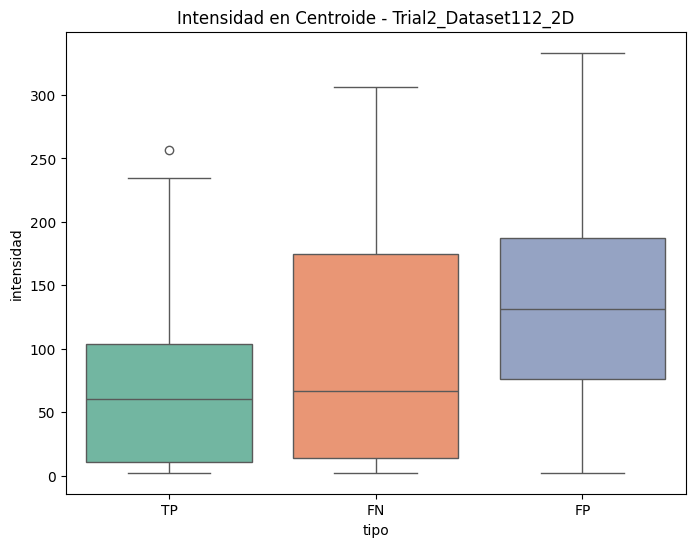

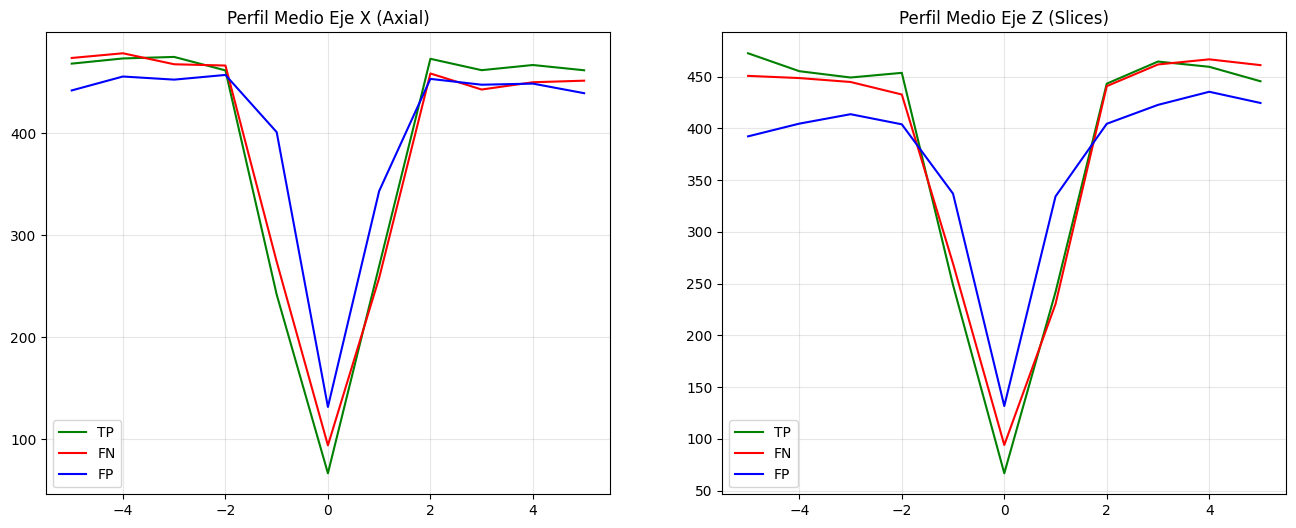

In [8]:
import os
import numpy as np
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.measure import label, regionprops
from tqdm import tqdm

# =================================================================
# CONFIGURACIÓN (Ejecutar una vez para Trial 1 y otra para Trial 2)
# =================================================================

TRIAL_NAME = "Trial2_Dataset112_2D"  # Identificador para el informe
EXCEL_PATH = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/CSIRO/CSIRO_dataset/rCMBInformationInfo.xlsx"
MASK_DIR = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/CSIRO/nnUNet_results/Dataset112_SyntheticCMB/nnUNet_2D_250epochs_predicciones_test_rCMBs" 
SWI_DIR = "/media/PORT-DISK/Practicas/MicroBleeds_Generation/CSIRO/CSIRO_Real_CMBs_Test/imagesTs" 
OUTPUT_BASE = f"/media/PORT-DISK/Practicas/MicroBleeds_Generation/CSIRO/nnUNet_results/Dataset112_SyntheticCMB/analisis_predicciones_sobre_rCMBs/{TRIAL_NAME}"

os.makedirs(OUTPUT_BASE, exist_ok=True)

# =================================================================
# UTILIDADES TÉCNICAS
# =================================================================

def get_sphere_offsets(radius=2):
    offsets = []
    for dx in range(-radius, radius + 1):
        for dy in range(-radius, radius + 1):
            for dz in range(-radius, radius + 1):
                if (dx**2 + dy**2 + dz**2) <= radius**2:
                    offsets.append((dx, dy, dz))
    return offsets

def extract_profile_1d(data, coords, axis=0, half_window=5):
    """Extrae perfil de intensidad en un eje específico (0=X, 2=Z)"""
    cx, cy, cz = map(int, coords)
    try:
        if axis == 0: # Eje X (Axial)
            return data[cx - half_window : cx + half_window + 1, cy, cz]
        elif axis == 2: # Eje Z (Slices)
            return data[cx, cy, cz - half_window : cz + half_window + 1]
    except IndexError:
        return None
    return None

def extract_patch_2d(data, coords, window=25):
    cx, cy, cz = map(int, coords)
    x_s, x_e = max(0, cx-window), min(data.shape[0], cx+window)
    y_s, y_e = max(0, cy-window), min(data.shape[1], cy+window)
    patch = data[x_s:x_e, y_s:y_e, cz]
    # Normalización para visualización
    patch = (patch - np.min(patch)) / (np.max(patch) - np.min(patch) + 1e-8)
    return np.rot90(patch)

# =================================================================
# PROCESAMIENTO
# =================================================================

sphere_offsets = get_sphere_offsets(radius=2)
df_excel = pd.read_excel(EXCEL_PATH)

profiles_x = {"TP": [], "FP": [], "FN": []}
profiles_z = {"TP": [], "FP": [], "FN": []}
patches = {"TP": [], "FP": [], "FN": []}
centroid_data = []

for idx, row in tqdm(df_excel.iterrows(), total=df_excel.shape[0]):
    base_name = str(row.iloc[0]).strip().replace(".nii.gz", "")
    mask_path = os.path.join(MASK_DIR, base_name + ".nii.gz")
    swi_path = os.path.join(SWI_DIR, base_name + "_0000.nii.gz")
    
    if not os.path.exists(mask_path) or not os.path.exists(swi_path): continue

    swi_data = nib.load(swi_path).get_fdata()
    mask_data = nib.load(mask_path).get_fdata()
    labeled_mask, num_blobs = label(mask_data > 0, return_num=True)
    
    # Coordenadas Reales (X, Y, Z restando 1)
    coords_gt = []
    for i in range(1, len(row), 3):
        try:
            # Cerciorando indexación 0-based y orden X,Y,Z
            c = [int(float(str(row.iloc[i+j]))) - 1 for j in range(3)]
            if c[0] >= 0: coords_gt.append(c)
        except: break

    # 1. TP y FN
    blobs_hit = set()
    for (cx, cy, cz) in coords_gt:
        is_tp = False
        for dx, dy, dz in sphere_offsets:
            nx, ny, nz = cx + dx, cy + dy, cz + dz
            if 0 <= nx < swi_data.shape[0] and 0 <= ny < swi_data.shape[1] and 0 <= nz < swi_data.shape[2]:
                if labeled_mask[nx, ny, nz] > 0:
                    blobs_hit.add(labeled_mask[nx, ny, nz])
                    is_tp = True
        
        tipo = "TP" if is_tp else "FN"
        centroid_data.append({'tipo': tipo, 'intensidad': swi_data[cx, cy, cz]})
        
        # Perfiles X y Z
        px = extract_profile_1d(swi_data, (cx, cy, cz), axis=0)
        pz = extract_profile_1d(swi_data, (cx, cy, cz), axis=2)
        if px is not None and len(px) == 11: profiles_x[tipo].append(px)
        if pz is not None and len(pz) == 11: profiles_z[tipo].append(pz)
        
        patch = extract_patch_2d(swi_data, (cx, cy, cz))
        if patch is not None:
            patches[tipo].append(patch)

    # 2. FP
    props = regionprops(labeled_mask, intensity_image=swi_data)
    for p in props:
        if p.label not in blobs_hit:
            bx, by, bz = map(int, p.centroid)
            centroid_data.append({'tipo': 'FP', 'intensidad': swi_data[bx, by, bz]})
            
            px = extract_profile_1d(swi_data, (bx, by, bz), axis=0)
            pz = extract_profile_1d(swi_data, (bx, by, bz), axis=2)
            if px is not None and len(px) == 11: profiles_x["FP"].append(px)
            if pz is not None and len(pz) == 11: profiles_z["FP"].append(pz)
            
            patch = extract_patch_2d(swi_data, (bx, by, bz))
            if patch is not None:
                patches["FP"].append(patch)

# =================================================================
# GRÁFICOS
# =================================================================

# 1. Boxplot con ORDEN FORZADO
plt.figure(figsize=(8, 6))
sns.boxplot(x='tipo', y='intensidad', data=pd.DataFrame(centroid_data), 
            order=['TP', 'FN', 'FP'], palette='Set2')
plt.title(f"Intensidad en Centroide - {TRIAL_NAME}")
plt.savefig(os.path.join(OUTPUT_BASE, "boxplot_intensidades.png"))

# 2. Perfiles Comparativos X y Z (added by me)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
x_ax = np.arange(-5, 6)

for tipo, color in zip(["TP", "FN", "FP"], ["green", "red", "blue"]):
    if profiles_x[tipo]:
        ax1.plot(x_ax, np.mean(profiles_x[tipo], axis=0), label=tipo, color=color)
        ax1.set_title("Perfil Medio Eje X (Axial)")
    if profiles_z[tipo]:
        ax2.plot(x_ax, np.mean(profiles_z[tipo], axis=0), label=tipo, color=color)
        ax2.set_title("Perfil Medio Eje Z (Slices)")

for ax in [ax1, ax2]:
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.savefig(os.path.join(OUTPUT_BASE, "perfiles_X_Z_comparativos.png"))


# 3. Cuadrículas 3x3
for tipo in ["TP", "FN", "FP"]:
    if patches[tipo]:
        fig, axes = plt.subplots(3, 3, figsize=(10, 10))
        plt.suptitle(f"Ejemplos de {tipo} ({TRIAL_NAME})", fontsize=16)
        for i, ax in enumerate(axes.flat):
            if i < len(patches[tipo]):
                ax.imshow(patches[tipo][i], cmap='gray')
            ax.axis('off')
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_BASE, f"grid_{tipo}.png"))
        plt.close()

print("Análisis finalizado.")

#### Generación de más cuadrículas de imagen

In [ ]:
import math

N = 9  # imágenes por grid

TRIAL_NAME = "Trial2_Dataset112_2D"
OUTPUT_BASE = f"/media/PORT-DISK/Practicas/MicroBleeds_Generation/CSIRO/nnUNet_results/Dataset112_SyntheticCMB/analisis_predicciones_sobre_rCMBs/{TRIAL_NAME}/example_images"


for tipo in ["TP", "FN", "FP"]:
    imgs = patches[tipo]
    if not imgs:
        continue

    num_imgs = len(imgs)
    num_grids = math.ceil(num_imgs / N)

    for g in range(num_grids):
        inicio = g * N
        fin = min((g + 1) * N, num_imgs)
        bloque = imgs[inicio:fin]

        fig, axes = plt.subplots(3, 3, figsize=(10, 10))
        plt.suptitle(f"Ejemplos de {tipo} ({TRIAL_NAME}) - grid {g+1}", fontsize=16)

        for i, ax in enumerate(axes.flat):
            if i < len(bloque):
                ax.imshow(bloque[i], cmap='gray')
            ax.axis('off')

        plt.tight_layout()
        fname = f"grid_{tipo}_{g+1}.png"  # grid_TP_1.png, grid_TP_2.png, etc.
        plt.savefig(os.path.join(OUTPUT_BASE, fname))
        plt.close()
